## Experiment 3 qubit Tutorial

In [14]:
# Import required libraries
import numpy as np
import optax
import matplotlib.pyplot as plt
from qsopt.core.experimental_parameters import (
    ExperimentalParameters,
    PhysicalConstants,
    SystemDimensions,
    MeasurementProtocol,
    InteractionType,
    QubitInteraction,
    InitialStateConfig,
    InitialStateType,
    NoiseConfiguration
)
from qsopt.core.circuit import QuantumCircuit, create_ry_circuit
from qsopt.core.gates import *
from qsopt.core.experiment.experiment import Experiment
from qsopt.core.loss_functions import DetectionMetric

# Suppress warnings for cleaner output
#import warnings
#warnings.filterwarnings('ignore')

## 1. Setup Experimental Parameters

In [ ]:
# Define experimental parameters using nested configuration objects
inverse_pulse_width = 1
gm = 15 * inverse_pulse_width
n_qubits = 3

interactions = [QubitInteraction(
    qubit_indices=(i, j),
    interaction_type=InteractionType.XX,
    chi=0.1
) for i in range(n_qubits) for j in range(n_qubits) if i!=j ]

physical_constants = PhysicalConstants(
    n_qubits=n_qubits,
    chi= 2.0*gm,
    photon_cavity_coupling=gm,
    inverse_pulse_width=inverse_pulse_width,
    qubit_interactions=interactions
)

system_dims = SystemDimensions(
    field_levels=2,
    cavity_levels=2,
    qubit_levels=2
)

measurement = MeasurementProtocol(
    measurement_times=list(np.array([-5.0, 5.0])/inverse_pulse_width)
)

initial_state = InitialStateConfig(state_type=InitialStateType.SINGLE_PHOTON)

noise_config = NoiseConfiguration(
    depolarizing=0.001,
    dephasing=0.001,
    relaxation=0.001
)

exp_params = ExperimentalParameters(
    physical_constants=physical_constants,
    system_dims=system_dims,
    measurement=measurement,
    initial_state=initial_state,
    noise_config=noise_config
)

print(exp_params)

SYSTEM DIMENSIONS
  Number of qubits:          3
  Cavity levels:             2
  Qubit levels:         [2, 2, 2]
  Field levels:              2
  Total dimension:          32
PHYSICAL CONSTANTS
  Chi:                  [30.0, 30.0, 30.0]
  Photon cavity coupling: 15.0000
  Inverse pulse width:    1.0000
  Qubit interactions:   6 interaction(s)
    [0] Qubits (0, 1): sx-sx, χ=0.1000
    [1] Qubits (0, 2): sx-sx, χ=0.1000
    [2] Qubits (0, 1): sx-sx, χ=0.1000
    [3] Qubits (1, 2): sx-sx, χ=0.1000
    [4] Qubits (0, 2): sx-sx, χ=0.1000
    [5] Qubits (1, 2): sx-sx, χ=0.1000
MEASUREMENT PROTOCOL
  Mode:                 Explicit list
  Number of measurements:      2
  Measurement times:    [-5.0, 5.0]
INITIAL STATE
  Type:                 single_photon
NOISE MODEL
  Depolarizing rate:    [0.0001, 0.0001, 0.0001]
  Dephasing rate:       [0.0001, 0.0001, 0.0001]
  Relaxation rate:      [0.0001, 0.0001, 0.0001]
  Custom operators:     None
SYSTEM STATUS
  Configuration:        VALID


## 2. Setup Trainable Parameters

For three-qubit experiments, we test multiple rotation layers and different circuit configurations

In [16]:
# Create three-qubit circuits with layered rotations

ini_circuit = create_ry_circuit(n_qubits=n_qubits, theta_values=np.pi/2)
ini_circuit.add_layer(gate_type = RZGate, parameters = np.pi/3)

fin_circuit = create_ry_circuit(n_qubits=n_qubits, theta_values=-np.pi/2)

print(ini_circuit)
print(fin_circuit)

ini_circuit_entangled = create_ry_circuit(n_qubits=n_qubits, theta_values=np.pi/4)
ini_circuit_entangled.add_entangling_layer(gate_type=CNOTGate, pattern="circular")
ini_circuit_entangled.add_layer(gate_type = RYGate, parameters= np.pi/4)
ini_circuit_entangled.add_layer(gate_type = RZGate, parameters = np.pi/3)

fin_circuit_entangled = create_ry_circuit(n_qubits=n_qubits, theta_values=-np.pi/4)
fin_circuit_entangled.add_entangling_layer(gate_type=CNOTGate, pattern="circular")
fin_circuit_entangled.add_layer(gate_type=RYGate, parameters= -np.pi/4)

print(ini_circuit_entangled)
print(fin_circuit_entangled)

QuantumCircuit(3 qubits, 6 gates)
  0: RY[0](param=1.571)
  1: RY[1](param=1.571)
  2: RY[2](param=1.571)
  3: RZ[0](param=1.047)
  4: RZ[1](param=1.047)
  5: RZ[2](param=1.047)
QuantumCircuit(3 qubits, 3 gates)
  0: RY[0](param=-1.571)
  1: RY[1](param=-1.571)
  2: RY[2](param=-1.571)
QuantumCircuit(3 qubits, 12 gates)
  0: RY[0](param=0.785)
  1: RY[1](param=0.785)
  2: RY[2](param=0.785)
  3: CNOT[(0, 1)]
  4: CNOT[(1, 2)]
  5: CNOT[(2, 0)]
  6: RY[0](param=0.785)
  7: RY[1](param=0.785)
  8: RY[2](param=0.785)
  9: RZ[0](param=1.047)
  10: RZ[1](param=1.047)
  11: RZ[2](param=1.047)
QuantumCircuit(3 qubits, 9 gates)
  0: RY[0](param=-0.785)
  1: RY[1](param=-0.785)
  2: RY[2](param=-0.785)
  3: CNOT[(0, 1)]
  4: CNOT[(1, 2)]
  5: CNOT[(2, 0)]
  6: RY[0](param=-0.785)
  7: RY[1](param=-0.785)
  8: RY[2](param=-0.785)


In [17]:
# Use max computational difference as the detection criterion for the detection metric
detection_metric = DetectionMetric(n_qubits=n_qubits, detection_criterion='max computational distance', detection_param=(4, 2.0))
print(detection_metric)


DetectionMetric: max computational distance with computational distance
detection criterion:
  'max computational distance'
metric:
  'computational distance'
batching logic:
  'max computational distance batching'
multiple measurement logic:
  'list aggregation'



## 3. Create Three-Qubit Experiment

Initialize the experiment with our parameters. This will:
- Generate operators for the 5-subsystem composite space (field x cavity x 3 qubits)
- Build the time-dependent Hamiltonian
- Cache initial state and projectors

In [18]:
experiment00 = Experiment(exp_params, ini_circuit, fin_circuit, detection_metric=detection_metric)
experiment10 = Experiment(exp_params, ini_circuit_entangled, fin_circuit, detection_metric=detection_metric)
#experiment11 = Experiment(exp_params, ini_circuit_entangled, fin_circuit_entangled, detection_metric=detection_metric)
#experiment01 = Experiment(exp_params, ini_circuit, fin_circuit_entangled, detection_metric=detection_metric)

## 4. Run Basic Simulation

In [19]:
# Run simulation with zero rotations
callback = experiment00.run_simulation(batch_size=1, measurement_times = [-5,5], states_probabilities=True)

print('Risultati della simulazione:' + '-'*60 + f'\n\n{callback}')

Risultati della simulazione:------------------------------------------------------------

MODE: Single Simulation
  Current Parameters:
     Initial circuit:
        param_0: 1.570796 rad (90.00°)
        param_1: 1.570796 rad (90.00°)
        param_2: 1.570796 rad (90.00°)
        param_3: 1.047198 rad (60.00°)
        param_4: 1.047198 rad (60.00°)
        param_5: 1.047198 rad (60.00°)
     Final circuit:
        param_0: -1.570796 rad (-90.00°)
        param_1: -1.570796 rad (-90.00°)
        param_2: -1.570796 rad (-90.00°)
  Detection Measures:
     With photon:    0.000000
     Without photon: 0.279506
     Metric:            -0.279506
  State Probabilities:
     With photon:
        000: 0.426827
        001: 0.110071
        010: 0.110071
        011: 0.052059
        100: 0.110071
        101: 0.052059
        110: 0.052059
        111: 0.086782
     Without photon:
        000: 0.420263
        001: 0.140803
        010: 0.140803
        011: 0.047174
        100: 0.140803
 

In [20]:
# Run simulation with zero rotations
callback = experiment10.run_simulation(batch_size=1, measurement_times = [-5,5], states_probabilities=True)

print('Risultati della simulazione:' + '-'*60 + f'\n\n{callback}')

Risultati della simulazione:------------------------------------------------------------

MODE: Single Simulation
  Current Parameters:
     Initial circuit:
        param_0: 0.785398 rad (45.00°)
        param_1: 0.785398 rad (45.00°)
        param_2: 0.785398 rad (45.00°)
        param_3: 0.785398 rad (45.00°)
        param_4: 0.785398 rad (45.00°)
        param_5: 0.785398 rad (45.00°)
        param_6: 1.047198 rad (60.00°)
        param_7: 1.047198 rad (60.00°)
        param_8: 1.047198 rad (60.00°)
     Final circuit:
        param_0: -1.570796 rad (-90.00°)
        param_1: -1.570796 rad (-90.00°)
        param_2: -1.570796 rad (-90.00°)
  Detection Measures:
     With photon:    0.000000
     Without photon: 0.257757
     Metric:            -0.257757
  State Probabilities:
     With photon:
        000: 0.301907
        001: 0.325481
        010: 0.157616
        011: 0.007152
        100: 0.157616
        101: 0.007152
        110: 0.035182
        111: 0.007892
     Without ph

## 5. Optimize Rotation Angles

Now let's optimize the rotation angles to maximize the metric.

In [21]:
# Optimize with max computational distance criterion
callback_opt_00 = experiment00.optimize_rotations(
    num_steps=100,
    batch_size=1,
    tolerance=1e-8,
    verbose=True,
    verbose_step=10,
    initial_values=[np.pi/3, np.pi/4, np.pi/4, np.pi/3, np.pi/3, np.pi/3, -np.pi/3, -np.pi, -np.pi/4],
    renormalize_grad=False,
    optimizer=optax.sgd(learning_rate=0.5)
)

Configuration:
    Max iterations: 100
    Batch size: 1
    Convergence tolerance: 1.00e-08
    Detection metric: max computational distance with computational distance
    Trainable parameters: 9 (6 initial circuit + 3 final circuit)
    Initial parameter values:
        param0.  setup_RY[0]  = 1.047  rad (60.0°)
        param1.  setup_RY[1]  = 0.785  rad (45.0°)
        param2.  setup_RY[2]  = 0.785  rad (45.0°)
        param3.  setup_RZ[0]  = 1.047  rad (60.0°)
        param4.  setup_RZ[1]  = 1.047  rad (60.0°)
        param5.  setup_RZ[2]  = 1.047  rad (60.0°)
        param6.  reset_RY[0]  = -1.047 rad (-60.0°)
        param7.  reset_RY[1]  = -3.142 rad (-180.0°)
        param8.  reset_RY[2]  = -0.785 rad (-45.0°)
Step  setup0_RY[0]   setup1_RY[1]   setup2_RY[2]   setup3_RZ[0]   reset0_RY[0]   reset1_RY[1]   reset2_RY[2]   Metric      Grad Norm   Time
-----------------------------------------------------------------------------------------------------------------------------------

0     1.047198       0.785398       0.785398       1.047198       -1.047198      -3.141593      -0.785398      -0.111638   1.32e-01    00h00m19s
1     1.041826       0.731370       0.768115       1.036542       -1.031432      -3.147626      -0.759343      -0.102937   1.31e-01    00h00m23s
2     1.036454       0.679268       0.750605       1.022698       -1.016239      -3.153966      -0.733943      -0.094514   1.27e-01    00h00m27s
10    1.014074       0.392881       0.648721       0.875628       -0.920666      -3.218264      -0.578157      -0.052526   6.71e-02    00h00m59s
20    1.042313       0.315090       0.631059       0.744249       -0.839390      -3.273441      -0.491460      -0.041194   3.34e-02    00h01m39s
30    1.091002       0.313120       0.637626       0.663749       -0.766695      -3.289351      -0.454115      -0.037019   2.52e-02    00h02m19s
40    1.146748       0.313661       0.638866       0.606388       -0.697053      -3.290600      -0.435890      -0.034239   2.22e-0

In [22]:
print(callback_opt_00)

MODE: Optimization
     Total iterations: 100
     Best epoch:        100
     Converged: False
     Final gradient norm: 1.345286e-02
  Best Parameters:
     Initial circuit:
        param_0: 1.437462 rad (82.36°)
        param_1: 0.311528 rad (17.85°)
        param_2: 0.561050 rad (32.15°)
        param_3: 0.322022 rad (18.45°)
        param_4: 1.013771 rad (58.08°)
        param_5: 0.639581 rad (36.65°)
     Final circuit:
        param_0: -0.351430 rad (-20.14°)
        param_1: -3.272605 rad (-187.51°)
        param_2: -0.375256 rad (-21.50°)
  Detection Measures:
     With photon:    0.000000
     Without photon: 0.023615
     Metric:            -0.023615
  State Probabilities:
     With photon:
        000: 0.344451
        001: 0.123129
        010: 0.007607
        011: 0.197818
        100: 0.155862
        101: 0.019735
        110: 0.012881
        111: 0.138518
     Without photon:
        000: 0.012803
        001: 0.000377
        010: 0.690406
        011: 0.020349
    

In [28]:
# Optimize again but adding entanglement, we start with previous optimal values for the single qubit rotations and add some initial entangling rotations

initial_circuit_params, final_circuit_params = callback_opt_00.get_best_trainable_params()

callback_opt_10 = experiment10.optimize_rotations(
    num_steps=100,
    batch_size=1,
    tolerance=1e-8,
    verbose=True,
    verbose_step=10,
    initial_values=[0, 0, 0] + initial_circuit_params + final_circuit_params,
    renormalize_grad=False,
    optimizer=optax.sgd(learning_rate=0.5)
)

Configuration:
    Max iterations: 100
    Batch size: 1
    Convergence tolerance: 1.00e-08
    Detection metric: max computational distance with computational distance
    Trainable parameters: 12 (9 initial circuit + 3 final circuit)
    Initial parameter values:
        param0.  setup_RY[0]  = 0.000  rad (0.0°)
        param1.  setup_RY[1]  = 0.000  rad (0.0°)
        param2.  setup_RY[2]  = 0.000  rad (0.0°)
        param3.  setup_RY[0]  = 1.437  rad (82.4°)
        param4.  setup_RY[1]  = 0.312  rad (17.8°)
        param5.  setup_RY[2]  = 0.561  rad (32.1°)
        param6.  setup_RZ[0]  = 0.322  rad (18.5°)
        param7.  setup_RZ[1]  = 1.014  rad (58.1°)
        param8.  setup_RZ[2]  = 0.640  rad (36.6°)
        param9.  reset_RY[0]  = -0.351 rad (-20.1°)
        param10. reset_RY[1]  = -3.273 rad (-187.5°)
        param11. reset_RY[2]  = -0.375 rad (-21.5°)
Step  setup0_RY[0]   setup1_RY[1]   setup2_RY[2]   setup3_RY[0]   reset0_RY[0]   reset1_RY[1]   reset2_RY[2]   Metric   

In [29]:
print(callback_opt_10)

MODE: Optimization
     Total iterations: 100
     Best epoch:        100
     Converged: False
     Final gradient norm: 4.297216e-03
  Best Parameters:
     Initial circuit:
        param_0: 0.274432 rad (15.72°)
        param_1: 0.036284 rad (2.08°)
        param_2: 0.118441 rad (6.79°)
        param_3: 1.314853 rad (75.34°)
        param_4: 0.298461 rad (17.10°)
        param_5: 0.490935 rad (28.13°)
        param_6: 0.244334 rad (14.00°)
        param_7: 0.930682 rad (53.32°)
        param_8: 0.571280 rad (32.73°)
     Final circuit:
        param_0: -0.147386 rad (-8.44°)
        param_1: -3.291093 rad (-188.57°)
        param_2: -0.372674 rad (-21.35°)
  Detection Measures:
     With photon:    0.000000
     Without photon: 0.016443
     Metric:            -0.016443
  State Probabilities:
     With photon:
        000: 0.246636
        001: 0.164924
        010: 0.004210
        011: 0.150309
        100: 0.213845
        101: 0.031566
        110: 0.006069
        111: 0.182440

### Visualize Optimization Progress

Let's plot how the metric evolved during optimization:


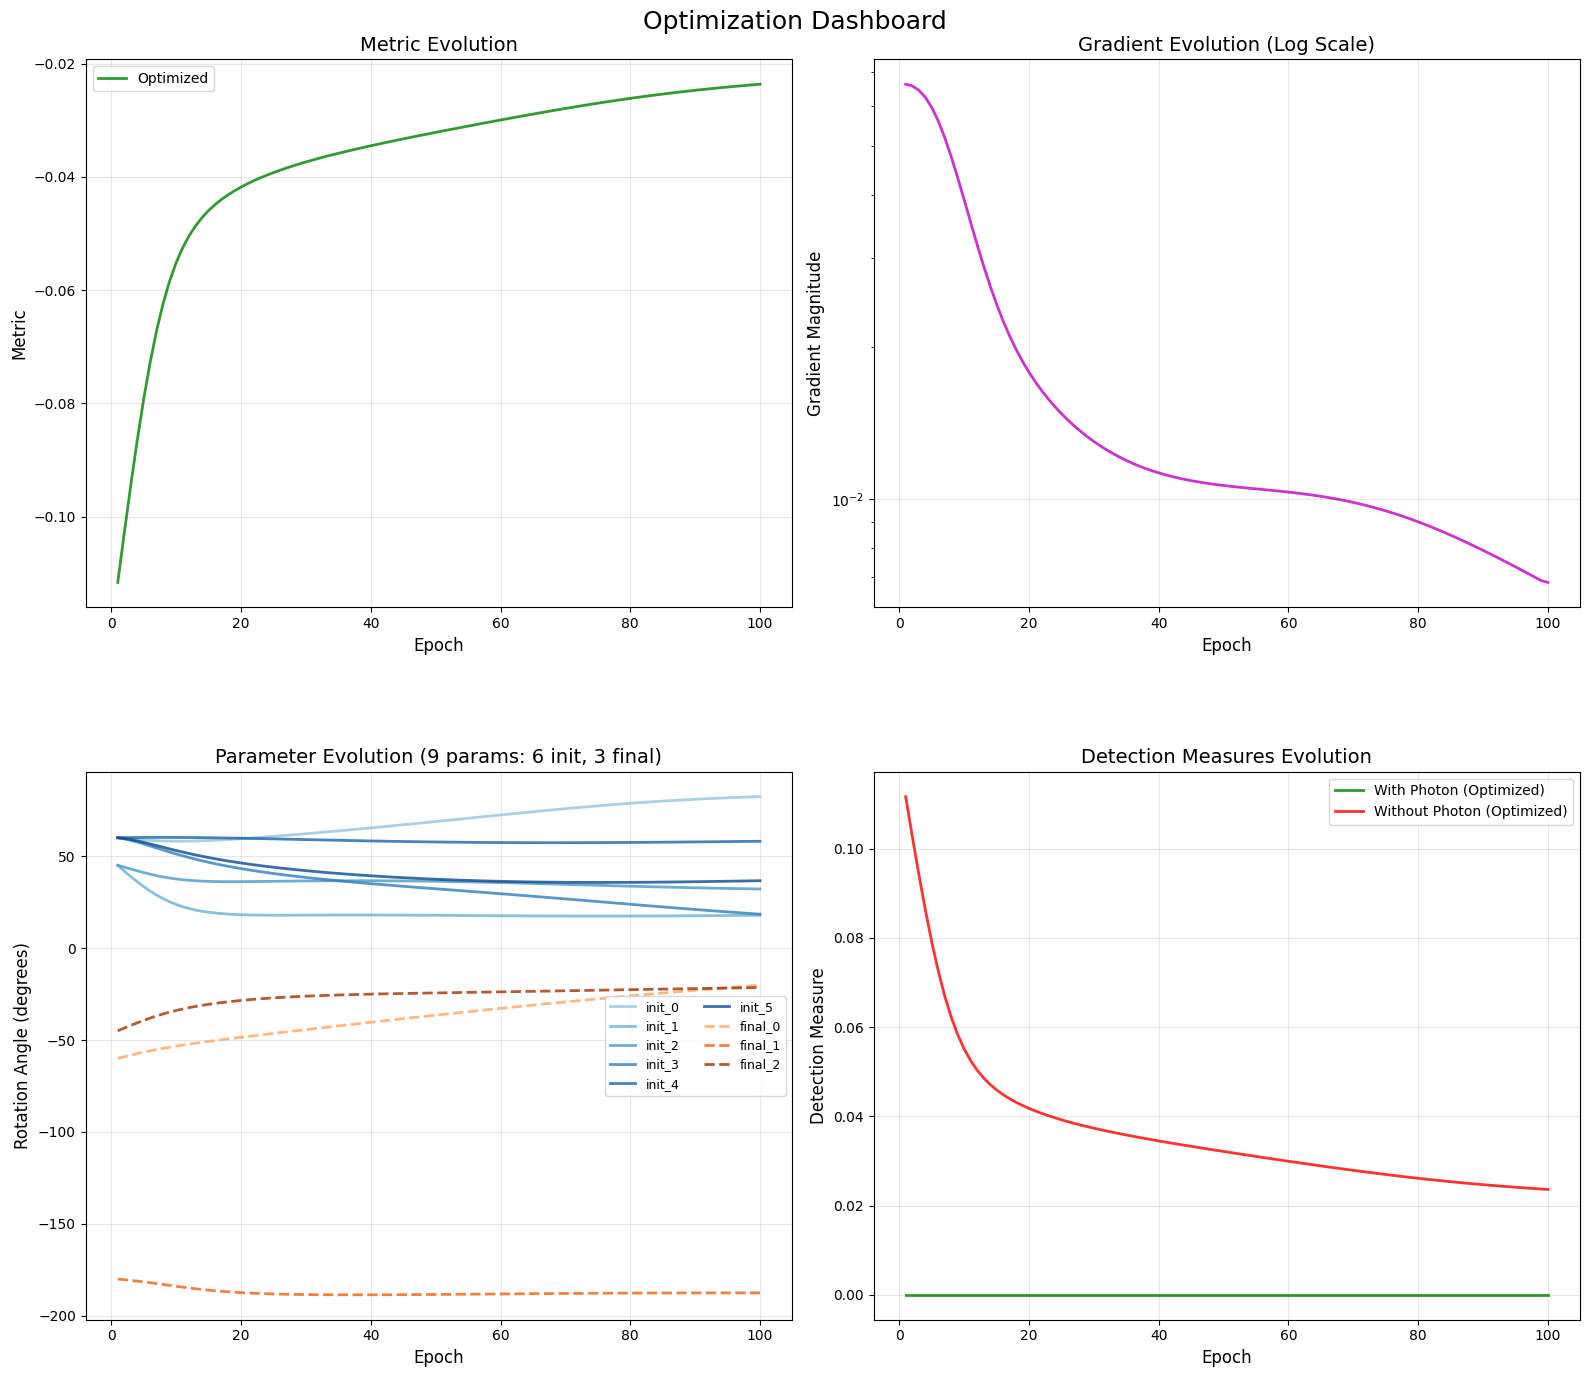

In [30]:
from qsopt.utils.visualization import plot_optimization_dashboard

# Create comprehensive dashboard showing all optimization metrics
fig = plot_optimization_dashboard(
    callback_opt_00,
    show_metric=True,
    show_gradients=True,
    show_parameters=True,
    show_trajectory=False,
    show_detection_measures=True,
    figsize=(16, 14)
)
plt.show()


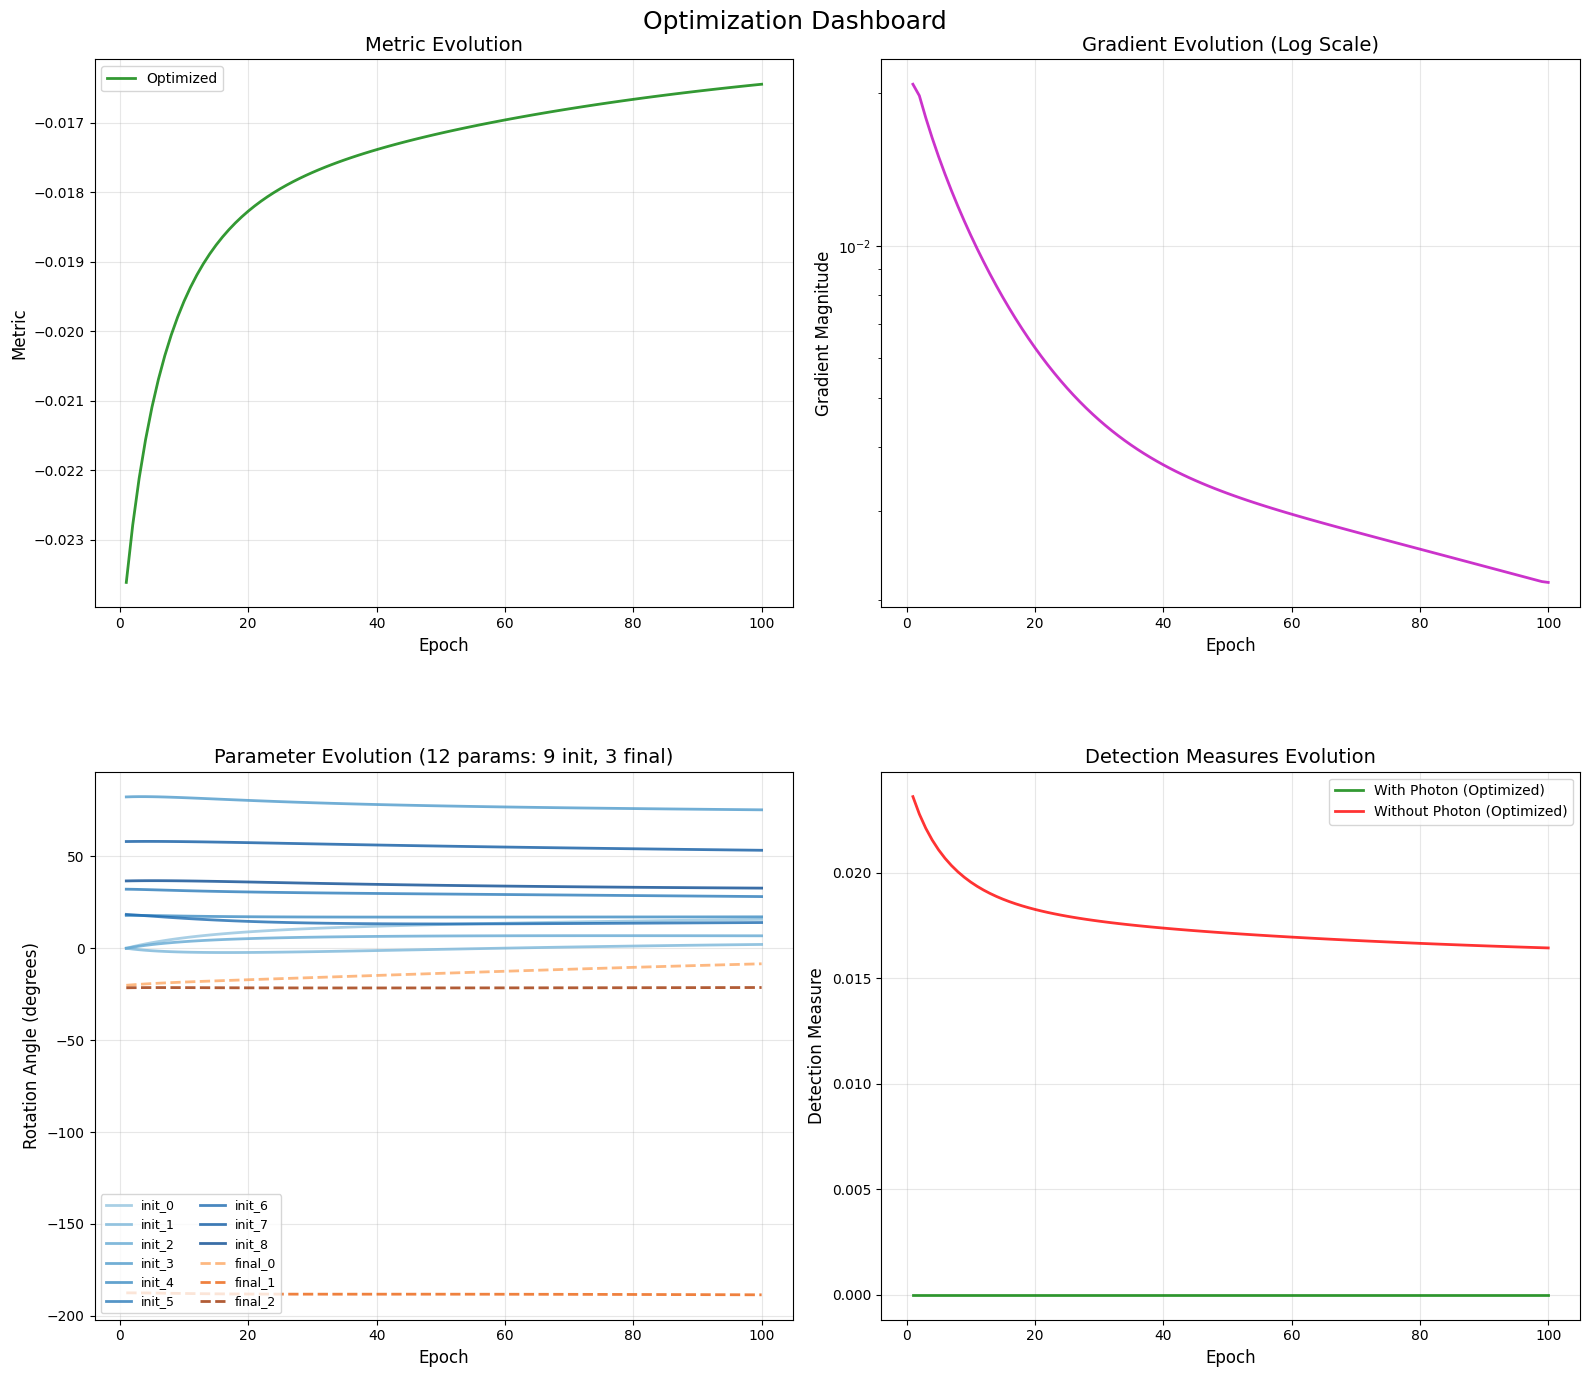

In [31]:
from qsopt.utils.visualization import plot_optimization_dashboard

# Create comprehensive dashboard showing all optimization metrics
fig = plot_optimization_dashboard(
    callback_opt_10,
    show_metric=True,
    show_gradients=True,
    show_parameters=True,
    show_trajectory=False,
    show_detection_measures=True,
    figsize=(16, 14)
)
plt.show()
